In [1]:
import sys
import pandas as pd
import numpy as np

# Add src to path so we can import forecast.py
sys.path.append("../src")

from forecasting.forecast import forecast_next_hour

print("Inference module loaded successfully!")


Inference module loaded successfully!


In [2]:
# AEP was trained in notebook 04 — load its feature data
aep_history = pd.read_csv(
    "../data/processed/features/AEP_features.csv"
)
aep_history["Datetime"] = pd.to_datetime(aep_history["Datetime"])
aep_history = aep_history.sort_values("Datetime").reset_index(drop=True)

print("AEP history rows:", len(aep_history))
print("Date range:", aep_history["Datetime"].min(), "→", aep_history["Datetime"].max())


AEP history rows: 121105
Date range: 2004-10-08 01:00:00 → 2018-08-03 00:00:00


In [3]:
test_index = 10000

history_slice = aep_history[["Datetime", "AEP_MW"]].iloc[:test_index]

result = forecast_next_hour(region="AEP", history_df=history_slice)

actual_next = aep_history["AEP_MW"].iloc[test_index]

print("=== SINGLE FORECAST TEST — AEP ===")
print(f"Source timestamp  : {result['source_timestamp']}")
print(f"Forecast timestamp: {result['forecast_timestamp']}")
print(f"Predicted MW      : {result['predicted_energy_MW']}")
print(f"Actual MW         : {actual_next}")
print(f"Error             : {abs(result['predicted_energy_MW'] - actual_next):.2f} MW")


=== SINGLE FORECAST TEST — AEP ===
Source timestamp  : 2005-11-28 19:00:00
Forecast timestamp: 2005-11-28 20:00:00
Predicted MW      : 16846.393
Actual MW         : 16944.0
Error             : 97.61 MW


In [4]:
backtest_indices = [5000, 10000, 20000, 40000, 60000, 80000, 90000, 100000, 110000, 115000]

backtest_results = []

for idx in backtest_indices:
    history_slice = aep_history[["Datetime", "AEP_MW"]].iloc[:idx]
    result = forecast_next_hour(region="AEP", history_df=history_slice)
    actual = aep_history["AEP_MW"].iloc[idx]
    error  = abs(result["predicted_energy_MW"] - actual)

    backtest_results.append({
        "region":              "AEP",
        "source_timestamp":    result["source_timestamp"],
        "forecast_timestamp":  result["forecast_timestamp"],
        "predicted_MW":        result["predicted_energy_MW"],
        "actual_MW":           actual,
        "abs_error_MW":        round(error, 2),
    })

backtest_df = pd.DataFrame(backtest_results)
print(backtest_df.to_string(index=False))
print(f"\nMean Absolute Error: {backtest_df['abs_error_MW'].mean():.2f} MW")


region    source_timestamp  forecast_timestamp  predicted_MW  actual_MW  abs_error_MW
   AEP 2005-05-04 10:00:00 2005-05-04 11:00:00     15999.026    15852.0        147.03
   AEP 2005-11-28 19:00:00 2005-11-28 20:00:00     16846.393    16944.0         97.61
   AEP 2007-01-19 13:00:00 2007-01-19 14:00:00     18688.293    18638.0         50.29
   AEP 2009-05-02 02:00:00 2009-05-02 03:00:00     10683.448    10576.0        107.45
   AEP 2011-08-13 15:00:00 2011-08-13 16:00:00     18395.738    18540.0        144.26
   AEP 2013-11-24 05:00:00 2013-11-24 06:00:00     15382.717    15373.0          9.72
   AEP 2015-01-14 22:00:00 2015-01-14 23:00:00     18519.412    18473.0         46.41
   AEP 2016-03-06 14:00:00 2016-03-06 15:00:00     13687.494    13389.0        298.49
   AEP 2017-04-27 07:00:00 2017-04-27 08:00:00     13740.080    13434.0        306.08
   AEP 2017-11-21 14:00:00 2017-11-21 15:00:00     14719.928    14571.0        148.93

Mean Absolute Error: 135.63 MW


In [5]:
# PJME was trained in notebook 03 — test it too
pjme_history = pd.read_csv(
    "../data/processed/features/PJME_features.csv"
)
pjme_history["Datetime"] = pd.to_datetime(pjme_history["Datetime"])
pjme_history = pjme_history.sort_values("Datetime").reset_index(drop=True)

history_slice = pjme_history[["Datetime", "PJME_MW"]].iloc[:50000]
result = forecast_next_hour(region="PJME", history_df=history_slice)
actual = pjme_history["PJME_MW"].iloc[50000]

print("=== SINGLE FORECAST TEST — PJME ===")
print(f"Source timestamp  : {result['source_timestamp']}")
print(f"Forecast timestamp: {result['forecast_timestamp']}")
print(f"Predicted MW      : {result['predicted_energy_MW']}")
print(f"Actual MW         : {actual}")
print(f"Error             : {abs(result['predicted_energy_MW'] - actual):.2f} MW")


=== SINGLE FORECAST TEST — PJME ===
Source timestamp  : 2007-09-22 19:00:00
Forecast timestamp: 2007-09-22 20:00:00
Predicted MW      : 37039.293
Actual MW         : 38222.0
Error             : 1182.71 MW


In [6]:
output_path = "../data/processed/predictions/one_hour_forecast_results.csv"
backtest_df.to_csv(output_path, index=False)

print("Saved:", output_path)
print("Rows:", len(backtest_df))
print("Columns:", list(backtest_df.columns))


Saved: ../data/processed/predictions/one_hour_forecast_results.csv
Rows: 10
Columns: ['region', 'source_timestamp', 'forecast_timestamp', 'predicted_MW', 'actual_MW', 'abs_error_MW']


In [8]:
# All 11 regions with their exact MW column names and feature files
ALL_REGIONS = [
    "AEP", "COMED", "DAYTON", "DEOK", "DOM",
    "DUQ", "EKPC", "FE", "NI", "PJME", "PJMW"
]

all_results = []

for region in ALL_REGIONS:

    print(f"\n{'='*50}")
    print(f"Testing: {region}")
    print(f"{'='*50}")

    # Load that region's feature data
    history = pd.read_csv(
        f"../data/processed/features/{region}_features.csv"
    )
    history["Datetime"] = pd.to_datetime(history["Datetime"])
    history = history.sort_values("Datetime").reset_index(drop=True)

    print(f"  Loaded {len(history)} rows | "
          f"{history['Datetime'].min()} → {history['Datetime'].max()}")

    # Pick 5 different timestamps spread across the dataset
    n = len(history)
    test_indices = [
        int(n * 0.20),
        int(n * 0.35),
        int(n * 0.50),
        int(n * 0.65),
        int(n * 0.80),
    ]

    for idx in test_indices:
        history_slice = history[["Datetime", f"{region}_MW"]].iloc[:idx]
        result = forecast_next_hour(region=region, history_df=history_slice)
        actual = history[f"{region}_MW"].iloc[idx]
        error  = abs(result["predicted_energy_MW"] - actual)
        pct    = round(error / actual * 100, 2)

        all_results.append({
            "region":             region,
            "source_timestamp":   result["source_timestamp"],
            "forecast_timestamp": result["forecast_timestamp"],
            "predicted_MW":       result["predicted_energy_MW"],
            "actual_MW":          round(actual, 1),
            "abs_error_MW":       round(error, 2),
            "error_pct":          pct,
        })

        print(f"  [{result['source_timestamp']}] → "
              f"Pred: {result['predicted_energy_MW']} | "
              f"Actual: {actual} | Error: {error:.1f} MW ({pct}%)")

print("\n✅ All 11 regions tested!")



Testing: AEP
  Loaded 121105 rows | 2004-10-08 01:00:00 → 2018-08-03 00:00:00
  [2007-07-14 11:00:00] → Pred: 15708.759 | Actual: 16203.0 | Error: 494.2 MW (3.05%)
  [2009-08-09 12:00:00] → Pred: 17814.344 | Actual: 18580.0 | Error: 765.7 MW (4.12%)
  [2011-09-05 15:00:00] → Pred: 13871.101 | Actual: 13784.0 | Error: 87.1 MW (0.63%)
  [2013-10-01 18:00:00] → Pred: 15531.217 | Actual: 15109.0 | Error: 422.2 MW (2.79%)
  [2015-10-28 19:00:00] → Pred: 14224.336 | Actual: 14565.0 | Error: 340.7 MW (2.34%)

Testing: COMED
  Loaded 66329 rows | 2011-01-08 01:00:00 → 2018-08-03 00:00:00
  [2012-07-13 20:00:00] → Pred: 15902.116 | Actual: 15809.0 | Error: 93.1 MW (0.59%)
  [2013-09-01 12:00:00] → Pred: 12526.614 | Actual: 12862.0 | Error: 335.4 MW (2.61%)
  [2014-10-21 03:00:00] → Pred: 8350.034 | Actual: 8194.0 | Error: 156.0 MW (1.9%)
  [2015-12-09 15:00:00] → Pred: 11312.055 | Actual: 11166.0 | Error: 146.1 MW (1.31%)
  [2017-01-27 05:00:00] → Pred: 10347.512 | Actual: 10045.0 | Error: 302

In [9]:
all_df = pd.DataFrame(all_results)

print("=== FULL BACKTEST RESULTS — ALL 11 REGIONS ===\n")
print(all_df.to_string(index=False))

print("\n=== MEAN ERROR PER REGION ===")
summary = all_df.groupby("region")["abs_error_MW"].mean().round(2)
print(summary.to_string())


=== FULL BACKTEST RESULTS — ALL 11 REGIONS ===

region    source_timestamp  forecast_timestamp  predicted_MW  actual_MW  abs_error_MW  error_pct
   AEP 2007-07-14 11:00:00 2007-07-14 12:00:00     15708.759    16203.0        494.24       3.05
   AEP 2009-08-09 12:00:00 2009-08-09 13:00:00     17814.344    18580.0        765.66       4.12
   AEP 2011-09-05 15:00:00 2011-09-05 16:00:00     13871.101    13784.0         87.10       0.63
   AEP 2013-10-01 18:00:00 2013-10-01 19:00:00     15531.217    15109.0        422.22       2.79
   AEP 2015-10-28 19:00:00 2015-10-28 20:00:00     14224.336    14565.0        340.66       2.34
 COMED 2012-07-13 20:00:00 2012-07-13 21:00:00     15902.116    15809.0         93.12       0.59
 COMED 2013-09-01 12:00:00 2013-09-01 13:00:00     12526.614    12862.0        335.39       2.61
 COMED 2014-10-21 03:00:00 2014-10-21 04:00:00      8350.034     8194.0        156.03       1.90
 COMED 2015-12-09 15:00:00 2015-12-09 16:00:00     11312.055    11166.0        

In [10]:
output_path = "../data/processed/predictions/one_hour_forecast_results.csv"

all_df.to_csv(output_path, index=False)

print(f"Saved: {output_path}")
print(f"Total rows: {len(all_df)}")
print(f"Regions covered: {all_df['region'].unique().tolist()}")
print(f"Columns: {list(all_df.columns)}")


Saved: ../data/processed/predictions/one_hour_forecast_results.csv
Total rows: 55
Regions covered: ['AEP', 'COMED', 'DAYTON', 'DEOK', 'DOM', 'DUQ', 'EKPC', 'FE', 'NI', 'PJME', 'PJMW']
Columns: ['region', 'source_timestamp', 'forecast_timestamp', 'predicted_MW', 'actual_MW', 'abs_error_MW', 'error_pct']


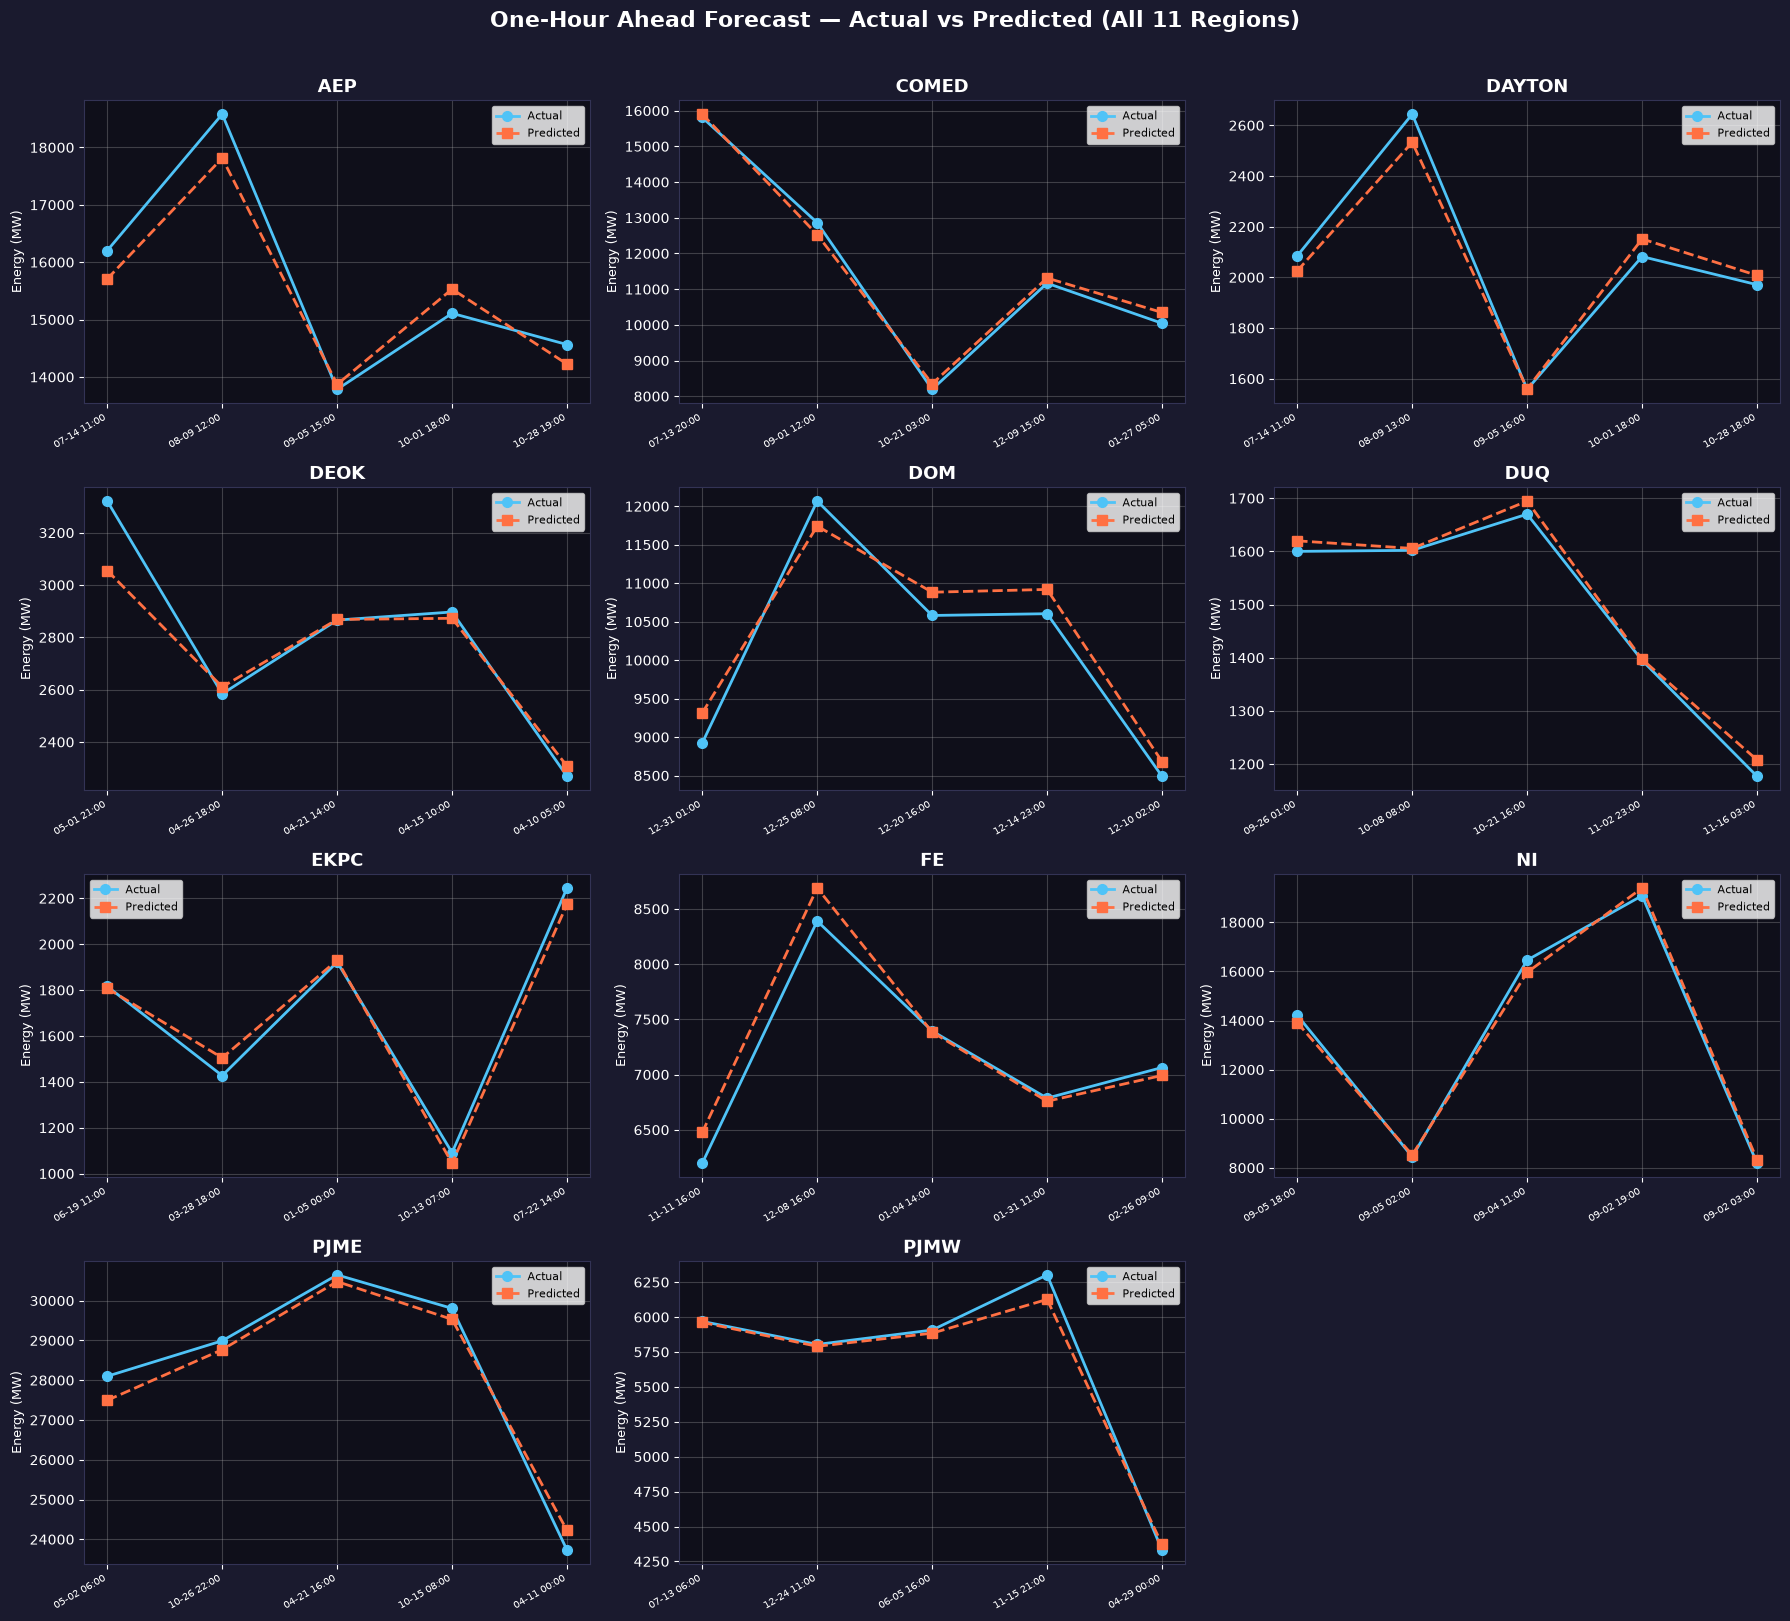

Graph saved!


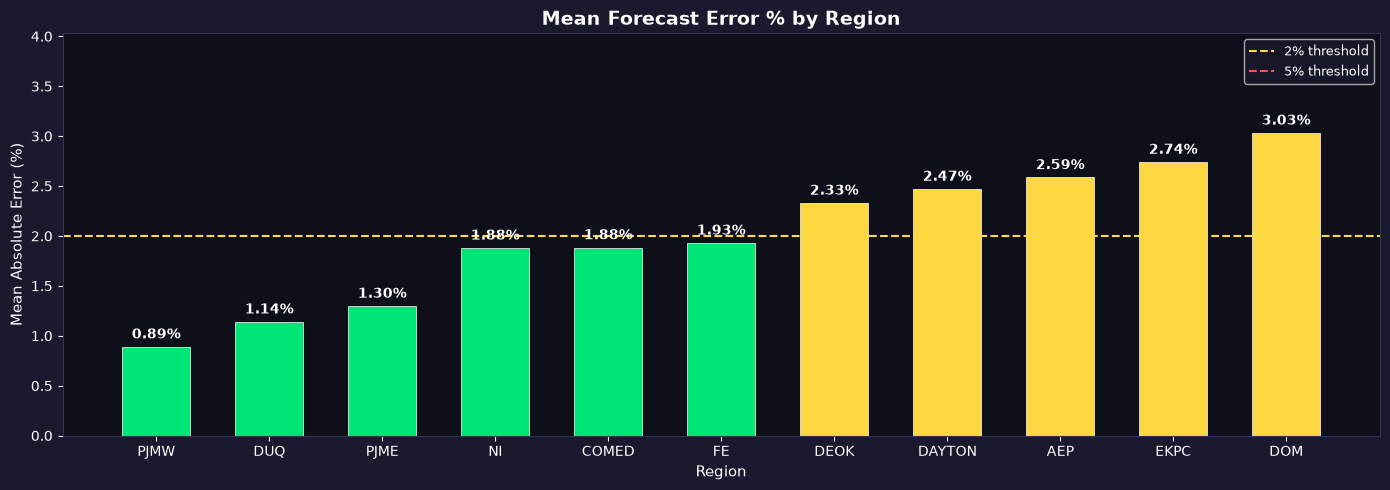

Error chart saved!


In [11]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd

df = pd.read_csv("../data/processed/predictions/one_hour_forecast_results.csv")

regions = df["region"].unique()

# ── Plot 1: Predicted vs Actual per region ──────────────────
fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.flatten()

for i, region in enumerate(regions):
    rdf = df[df["region"] == region].reset_index(drop=True)
    x = range(len(rdf))

    axes[i].plot(x, rdf["actual_MW"],    "o-", color="#4FC3F7", linewidth=2,
                 markersize=7, label="Actual")
    axes[i].plot(x, rdf["predicted_MW"], "s--", color="#FF7043", linewidth=2,
                 markersize=7, label="Predicted")

    axes[i].set_title(f"{region}", fontsize=13, fontweight="bold")
    axes[i].set_ylabel("Energy (MW)", fontsize=9)
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(
        [t[5:16] for t in rdf["source_timestamp"]],
        rotation=30, fontsize=7, ha="right"
    )
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)
    axes[i].set_facecolor("#0f0f1a")
    fig.patch.set_facecolor("#1a1a2e")
    axes[i].tick_params(colors="white")
    axes[i].title.set_color("white")
    axes[i].yaxis.label.set_color("white")
    for spine in axes[i].spines.values():
        spine.set_edgecolor("#333355")

# Hide the 12th subplot (we only have 11 regions)
axes[11].set_visible(False)

fig.suptitle("One-Hour Ahead Forecast — Actual vs Predicted (All 11 Regions)",
             fontsize=16, fontweight="bold", color="white", y=1.01)
plt.tight_layout()
plt.savefig("../data/processed/predictions/forecast_vs_actual.png",
            dpi=150, bbox_inches="tight", facecolor="#1a1a2e")
plt.show()
print("Graph saved!")

# ── Plot 2: Error % per region (bar chart) ───────────────────
fig2, ax = plt.subplots(figsize=(14, 5))
fig2.patch.set_facecolor("#1a1a2e")
ax.set_facecolor("#0f0f1a")

region_avg = df.groupby("region")["error_pct"].mean().sort_values()
colors = ["#00E676" if v < 2 else "#FFD740" if v < 4 else "#FF5252"
          for v in region_avg.values]

bars = ax.bar(region_avg.index, region_avg.values, color=colors,
              edgecolor="white", linewidth=0.5, width=0.6)

ax.axhline(y=2, color="#FFD740", linestyle="--", linewidth=1.5,
           label="2% threshold")
ax.axhline(y=5, color="#FF5252", linestyle="--", linewidth=1.5,
           label="5% threshold")

for bar, val in zip(bars, region_avg.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f"{val:.2f}%", ha="center", va="bottom",
            color="white", fontsize=10, fontweight="bold")

ax.set_title("Mean Forecast Error % by Region",
             fontsize=14, fontweight="bold", color="white")
ax.set_xlabel("Region", color="white", fontsize=11)
ax.set_ylabel("Mean Absolute Error (%)", color="white", fontsize=11)
ax.tick_params(colors="white")
ax.legend(fontsize=9, facecolor="#1a1a2e", labelcolor="white")
ax.set_ylim(0, max(region_avg.values) + 1)
for spine in ax.spines.values():
    spine.set_edgecolor("#333355")

plt.tight_layout()
plt.savefig("../data/processed/predictions/forecast_error_by_region.png",
            dpi=150, bbox_inches="tight", facecolor="#1a1a2e")
plt.show()
print("Error chart saved!")
